# Social Networks Analysis Project

## Import Necessary Libraries
First, we import necessary libraries used for loading, preprocessing the data, graph visualization and data evaluation.

In [1]:
# import necessary libraries

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np

## Read the data

Then, we read the dataset so that it will be utilized during the project.

In [2]:
# read the data

df = pd.read_csv(
    "sx-stackoverflow.txt",
    sep=r"\s+",
    header=None,
    names=["source", "target", "timestamp"]
)

## Data Analysis on Edges, Columns and Missing Values

We perform data analysis on the dataset's edges and columns as well as missing values contained in it.
Additionally, the timestamp is included so that we filter oldest vs. newest timestamp.

In [3]:
# perform data analysis on the dataset's edges, columns, and missing values

print("Number of edges:", len(df))
print("Number of columns:", len(df.columns))

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

# perform data analysis on the timestamp
print("Oldest timestamp:", df["timestamp"].min())
print("Latest timestamp:", df["timestamp"].max())

Number of edges: 63497050
Number of columns: 3

Data types:
source       int64
target       int64
timestamp    int64
dtype: object

Missing values:
source       0
target       0
timestamp    0
dtype: int64
Oldest timestamp: 1217567877
Latest timestamp: 1457273428


## N-value Specification

We then specify a N-value, so that we need to validate equal-duration periods since it gives us enough temporal resolution to observe evolution
while keeping the subsequent centrality analysis.

Later, we calculate the time boundaries.

In [4]:
# N-value specification
N = 10

tmin = df["timestamp"].min()
tmax = df["timestamp"].max()

delta_t = (tmax - tmin) / N

print("N =", N)
print("tmin =", tmin)
print("tmax =", tmax)
print("ΔT =", tmax - tmin)
print("δt =", delta_t)

N = 10
tmin = 1217567877
tmax = 1457273428
ΔT = 239705551
δt = 23970555.1


In [5]:
# calculate time boundaries

time_points = [
    tmin + j * delta_t
    for j in range(N + 1)
]

for j, t in enumerate(time_points):
    print(f"t{j} = {t}")

t0 = 1217567877.0
t1 = 1241538432.1
t2 = 1265508987.2
t3 = 1289479542.3
t4 = 1313450097.4
t5 = 1337420652.5
t6 = 1361391207.6
t7 = 1385361762.7
t8 = 1409332317.8
t9 = 1433302872.9
t10 = 1457273428.0


# Create Temporal Subgraphs

Prior to creation of temporal subgraphs, we first determine the number of edges on each period.

In [6]:
# create temporal subgraphs
period_counts = []

for j in range(N):
    start = time_points[j]
    end = time_points[j + 1]

    if j < N - 1:
        mask = (
            (df["timestamp"] >= start) &
            (df["timestamp"] < end)
        )
    else:
        mask = (
            (df["timestamp"] >= start) &
            (df["timestamp"] <= end)
        )

    count = mask.sum()
    period_counts.append(count)

    print(f"T{j + 1}: {count:,} edges")

# verify sum, length and difference
print("\nTotal assigned edges:", sum(period_counts))
print("Original edges:", len(df))
print("Difference:", len(df) - sum(period_counts))

T1: 813,739 edges
T2: 1,895,644 edges
T3: 2,942,326 edges
T4: 4,890,511 edges
T5: 6,263,519 edges
T6: 7,873,629 edges
T7: 9,481,054 edges
T8: 9,935,186 edges
T9: 9,282,517 edges
T10: 10,118,925 edges

Total assigned edges: 63497050
Original edges: 63497050
Difference: 0


# Choose Graph Representation

In this part, we choose a graph representation for our dataset.
Since there are undirected subgraphs, the most common choice is a NetworkX graph.

Note that the file contains timestamped edge records, which means that the timestamp is no longer stored on the edge.

In [7]:
# choose graph representation

start = time_points[0]
end = time_points[1]

period_1 = df[
    (df["timestamp"] >= start) &
    (df["timestamp"] < end)
]

G1 = nx.from_pandas_edgelist(
    period_1,
    source="source",
    target="target",
    create_using=nx.Graph()
)

G1.remove_edges_from(nx.selfloop_edges(G1))

print("G1 nodes:", G1.number_of_nodes())
print("G1 edges:", G1.number_of_edges())
print("Number of self-loops:", nx.number_of_selfloops(G1))

G1 nodes: 32888
G1 edges: 496620
Number of self-loops: 0


## Create All Period Graphs

Since G1 is now clean, we create the 10 temporal graphs using the same procedure as above.

In [8]:
# create all period graphs

graphs = []

for j in range(N):
    start = time_points[j]
    end = time_points[j + 1]

    if j < N - 1:
        period_df = df[
            (df["timestamp"] >= start) &
            (df["timestamp"] < end)
        ]
    else:
        period_df = df[
            (df["timestamp"] >= start) &
            (df["timestamp"] <= end)
        ]

    G = nx.from_pandas_edgelist(
        period_df,
        source="source",
        target="target",
        create_using=nx.Graph()
    )

    # Remove self-loops
    G.remove_edges_from(nx.selfloop_edges(G))

    graphs.append(G)

    print(
        f"T{j + 1}: "
        f"{G.number_of_nodes():,} nodes, "
        f"{G.number_of_edges():,} edges"
    )

T1: 32,888 nodes, 496,620 edges
T2: 91,139 nodes, 1,012,026 edges
T3: 187,011 nodes, 1,470,491 edges
T4: 319,421 nodes, 2,305,798 edges
T5: 423,668 nodes, 2,895,693 edges
T6: 572,267 nodes, 3,516,687 edges
T7: 748,973 nodes, 4,255,052 edges
T8: 854,705 nodes, 4,406,668 edges
T9: 928,934 nodes, 4,145,454 edges
T10: 1,024,422 nodes, 4,474,425 edges


# Number of nodes (V) and edges (E)

We then calculate the number of nodes (V) and edges (E).

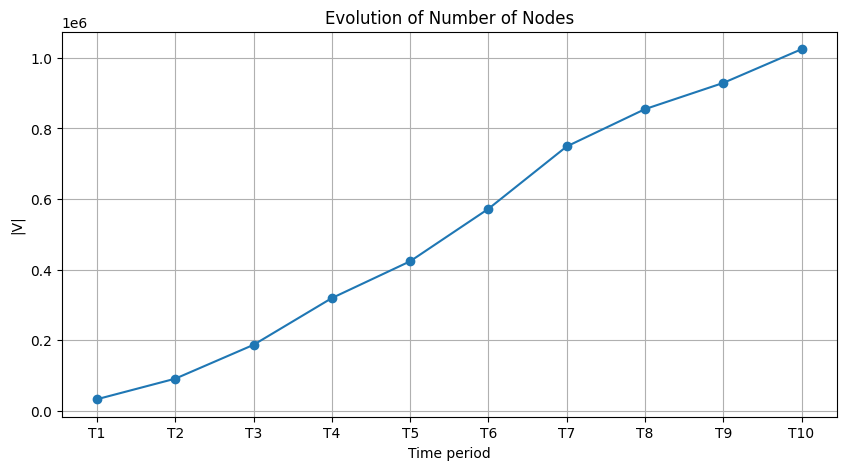

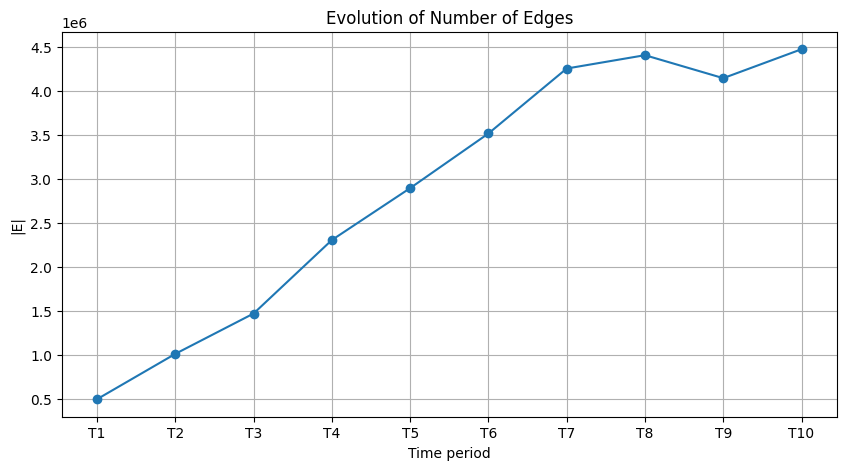

In [9]:
num_nodes = [G.number_of_nodes() for G in graphs]
num_edges = [G.number_of_edges() for G in graphs]

period_labels = [f"T{i}" for i in range(1, N + 1)]

plt.figure(figsize=(10, 5))
plt.plot(period_labels, num_nodes, marker="o")
plt.xlabel("Time period")
plt.ylabel("|V|")
plt.title("Evolution of Number of Nodes")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(period_labels, num_edges, marker="o")
plt.xlabel("Time period")
plt.ylabel("|E|")
plt.title("Evolution of Number of Edges")
plt.grid(True)
plt.show()

## Calculate Degree Centrality for All Periods

Before moving on to the centralities of all five periods, we calculate degree centrality for all periods first.
Later, we plot the centrality for each period distribution.

In [10]:
# calculate degree centrality for all periods

degree_centralities = []

for i, G in enumerate(graphs, start=1):
    print(f"Calculating degree centrality for T{i}...")

    centrality = nx.degree_centrality(G)
    degree_centralities.append(centrality)

    print(f"  Calculated for {len(centrality):,} nodes")

Calculating degree centrality for T1...
  Calculated for 32,888 nodes
Calculating degree centrality for T2...
  Calculated for 91,139 nodes
Calculating degree centrality for T3...
  Calculated for 187,011 nodes
Calculating degree centrality for T4...
  Calculated for 319,421 nodes
Calculating degree centrality for T5...
  Calculated for 423,668 nodes
Calculating degree centrality for T6...
  Calculated for 572,267 nodes
Calculating degree centrality for T7...
  Calculated for 748,973 nodes
Calculating degree centrality for T8...
  Calculated for 854,705 nodes
Calculating degree centrality for T9...
  Calculated for 928,934 nodes
Calculating degree centrality for T10...
  Calculated for 1,024,422 nodes


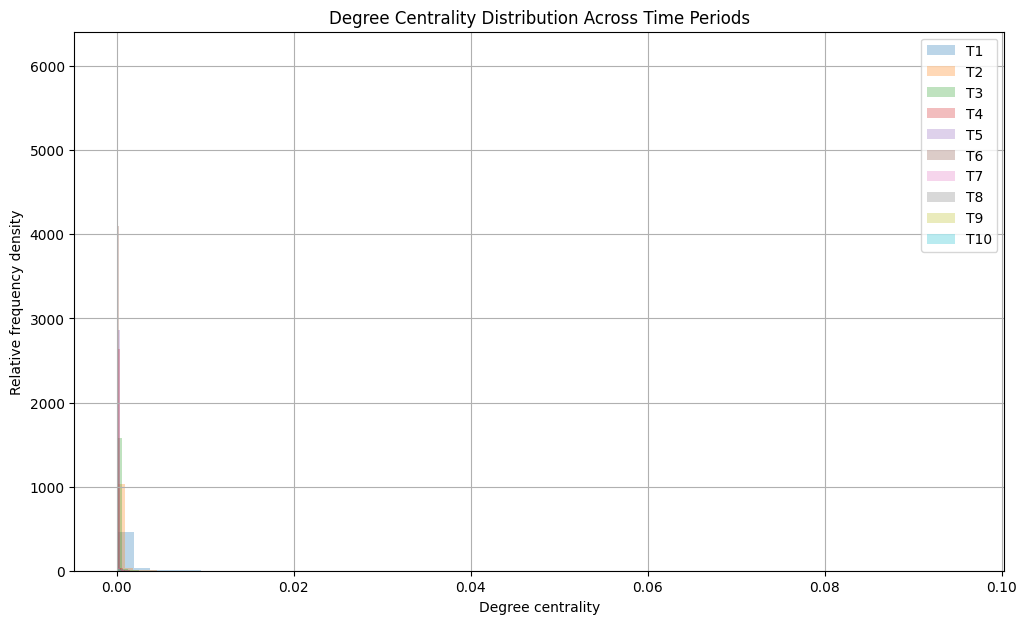

In [11]:
# plot for each period distribution

plt.figure(figsize=(12, 7))

for i, centrality in enumerate(degree_centralities, start=1):
    values = list(centrality.values())

    plt.hist(
        values,
        bins=50,
        density=True,
        alpha=0.3,
        label=f"T{i}"
    )

plt.xlabel("Degree centrality")
plt.ylabel("Relative frequency density")
plt.title("Degree Centrality Distribution Across Time Periods")
plt.legend()
plt.grid(True)
plt.show()

## Calculate Closeness Centrality

Then, we calculate closeness centrality for all 10 periods on a fixed number of samples.

Note that closeness centrality is much more computationally expensive than degree centrality because the graphs have up to 1 million nodes.

In [12]:
# calculate closeness centrality for all 10 nodes and 50 random samples

closeness_centralities = []

sample_size = 50

for i, G in enumerate(graphs, start=1):
    print(f"Calculating sampled closeness centrality for T{i}...")

    sampled_nodes = random.sample(
        list(G.nodes()),
        min(sample_size, G.number_of_nodes())
    )

    centrality = {}

    for node in sampled_nodes:
        distances = nx.single_source_shortest_path_length(G, node)

        if len(distances) > 1:
            total_distance = sum(distances.values())
            centrality[node] = (len(distances) - 1) / total_distance
        else:
            centrality[node] = 0

    closeness_centralities.append(centrality)

    print(f"  Calculated for {len(centrality):,} sampled nodes")

Calculating sampled closeness centrality for T1...
  Calculated for 50 sampled nodes
Calculating sampled closeness centrality for T2...
  Calculated for 50 sampled nodes
Calculating sampled closeness centrality for T3...
  Calculated for 50 sampled nodes
Calculating sampled closeness centrality for T4...
  Calculated for 50 sampled nodes
Calculating sampled closeness centrality for T5...
  Calculated for 50 sampled nodes
Calculating sampled closeness centrality for T6...
  Calculated for 50 sampled nodes
Calculating sampled closeness centrality for T7...
  Calculated for 50 sampled nodes
Calculating sampled closeness centrality for T8...
  Calculated for 50 sampled nodes
Calculating sampled closeness centrality for T9...
  Calculated for 50 sampled nodes
Calculating sampled closeness centrality for T10...
  Calculated for 50 sampled nodes


## Plot Closeness Distributions

Since these are sampled values, the plot represents the sampled/estimated distribution of closeness centrality.

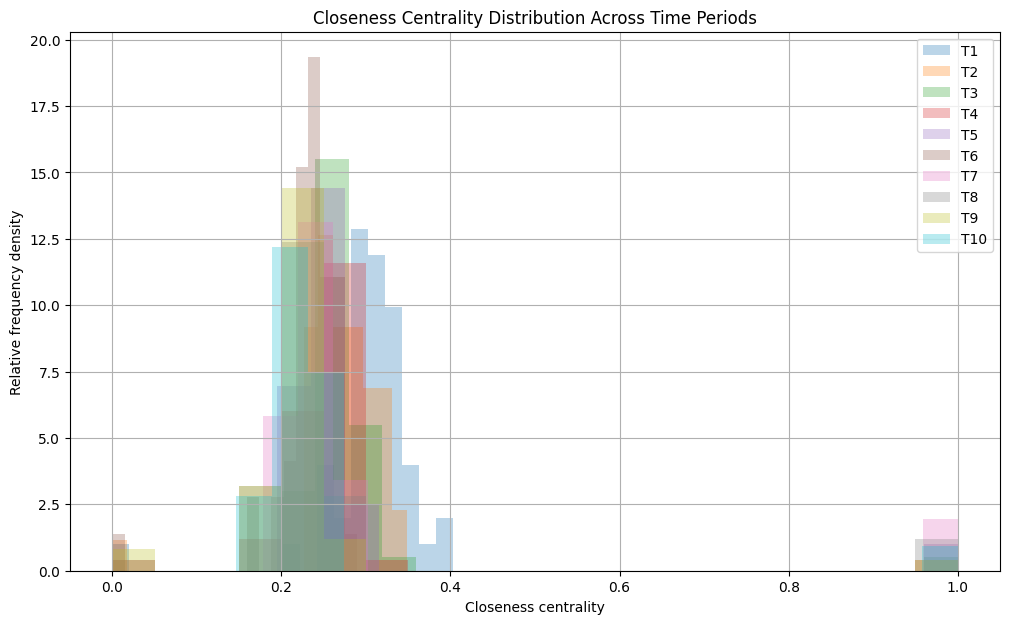

In [13]:
# plot closeness distributions

plt.figure(figsize=(12, 7))

for i, centrality in enumerate(closeness_centralities, start=1):
    values = list(centrality.values())

    plt.hist(
        values,
        bins=20,
        density=True,
        alpha=0.3,
        label=f"T{i}"
    )

plt.xlabel("Closeness centrality")
plt.ylabel("Relative frequency density")
plt.title("Closeness Centrality Distribution Across Time Periods")
plt.legend()
plt.grid(True)
plt.show()

## Test Betweenness Centrality on One Node

Before testing on all 10 nodes, we test closeness centrality on one node first.

In [14]:
# test closeness centrality on one node

print("Calculating approximate betweenness centrality for T1...")

betweenness_T1 = nx.betweenness_centrality(
    graphs[0],
    k=10,
    seed=42
)

print(f"Calculated for {len(betweenness_T1):,} nodes")

Calculating approximate betweenness centrality for T1...
Calculated for 32,888 nodes


## Calculating Betweenness Centrality for all 10 Periods

Later, we calculate betweenness centrality for all 10 periods.

In [15]:
# calculate betweenness centrality for all 10 periods

betweenness_centralities = []

sample_size = 10

for i, G in enumerate(graphs, start=1):
    print(f"Calculating sampled betweenness centrality for T{i}...")

    sampled_nodes = random.sample(
        list(G.nodes()),
        min(sample_size, G.number_of_nodes())
    )

    centrality = nx.betweenness_centrality_subset(
        G,
        sources=sampled_nodes,
        targets=list(G.nodes()),
        normalized=True
    )

    # Keep only the sampled nodes for the distribution
    sampled_centrality = {
        node: centrality[node]
        for node in sampled_nodes
    }

    betweenness_centralities.append(sampled_centrality)

    print(f"  Calculated for {len(sampled_centrality):,} sampled nodes")

Calculating sampled betweenness centrality for T1...
  Calculated for 10 sampled nodes
Calculating sampled betweenness centrality for T2...
  Calculated for 10 sampled nodes
Calculating sampled betweenness centrality for T3...
  Calculated for 10 sampled nodes
Calculating sampled betweenness centrality for T4...
  Calculated for 10 sampled nodes
Calculating sampled betweenness centrality for T5...
  Calculated for 10 sampled nodes
Calculating sampled betweenness centrality for T6...
  Calculated for 10 sampled nodes
Calculating sampled betweenness centrality for T7...
  Calculated for 10 sampled nodes
Calculating sampled betweenness centrality for T8...
  Calculated for 10 sampled nodes
Calculating sampled betweenness centrality for T9...
  Calculated for 10 sampled nodes
Calculating sampled betweenness centrality for T10...
  Calculated for 10 sampled nodes


## Plot 10 sampled values for each period

Later, we plot 10 sampled betweenness values for each period.

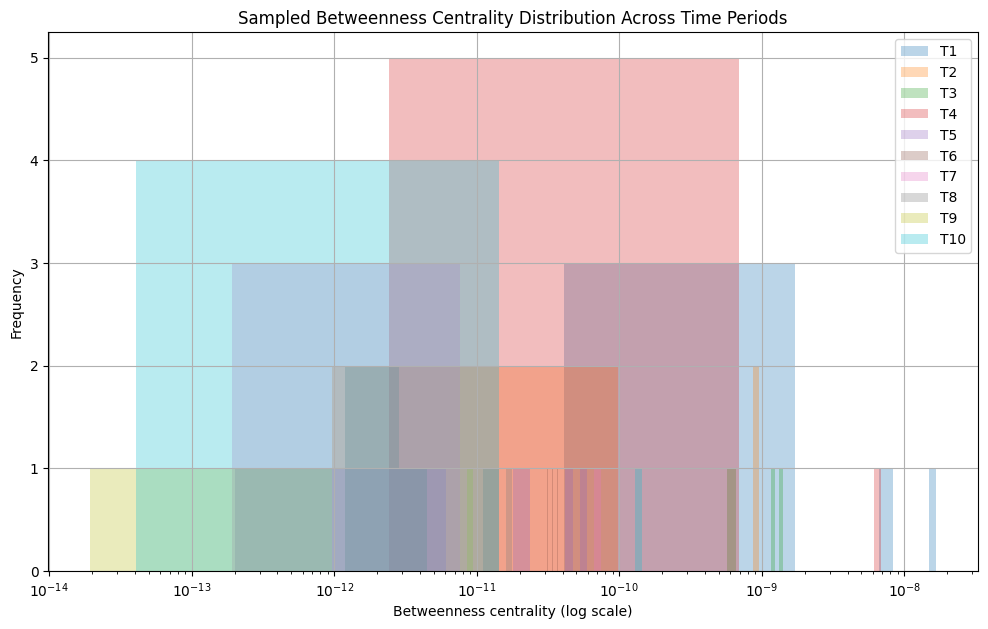

In [16]:
# plot 10 betweenness values

plt.figure(figsize=(12, 7))

for i, centrality in enumerate(betweenness_centralities, start=1):
    values = [v for v in centrality.values() if v > 0]

    if values:
        plt.hist(
            values,
            bins=10,
            alpha=0.3,
            label=f"T{i}"
        )

plt.xscale("log")
plt.xlabel("Betweenness centrality (log scale)")
plt.ylabel("Frequency")
plt.title("Sampled Betweenness Centrality Distribution Across Time Periods")
plt.legend()
plt.grid(True)
plt.show()

## Calculate Eigenvector Centrality

We move to calculation of Eigenvector centrality in the current example and begin with the first node.
Additionally, we examine the other centralities.

In [17]:
# calculate eigenvector centrality

print("Calculating eigenvector centrality for T1...")

eigenvector_T1 = nx.eigenvector_centrality(
    graphs[0],
    max_iter=100,
    tol=1e-06
)

print(f"Calculated for {len(eigenvector_T1):,} nodes")

# print min and max values
print("Minimum:", min(eigenvector_T1.values()))
print("Maximum:", max(eigenvector_T1.values()))
print("Mean:", np.mean(list(eigenvector_T1.values())))

Calculating eigenvector centrality for T1...
Calculated for 32,888 nodes
Minimum: 9.603111435819816e-19
Maximum: 0.15202590227295798
Mean: 0.0021746876619041767


In [18]:
# examine the other centralities
eigenvector_centralities = []

for i, G in enumerate(graphs, start=1):
    print(f"Calculating eigenvector centrality for T{i}...")

    centrality = nx.eigenvector_centrality(
        G,
        max_iter=100,
        tol=1e-06
    )

    eigenvector_centralities.append(centrality)

    print(f"  Calculated for {len(centrality):,} nodes")

Calculating eigenvector centrality for T1...
  Calculated for 32,888 nodes
Calculating eigenvector centrality for T2...
  Calculated for 91,139 nodes
Calculating eigenvector centrality for T3...
  Calculated for 187,011 nodes
Calculating eigenvector centrality for T4...
  Calculated for 319,421 nodes
Calculating eigenvector centrality for T5...
  Calculated for 423,668 nodes
Calculating eigenvector centrality for T6...
  Calculated for 572,267 nodes
Calculating eigenvector centrality for T7...
  Calculated for 748,973 nodes
Calculating eigenvector centrality for T8...
  Calculated for 854,705 nodes
Calculating eigenvector centrality for T9...
  Calculated for 928,934 nodes
Calculating eigenvector centrality for T10...
  Calculated for 1,024,422 nodes


## Plot Eigenvector values for each period

We plot eigenvector values for each period.

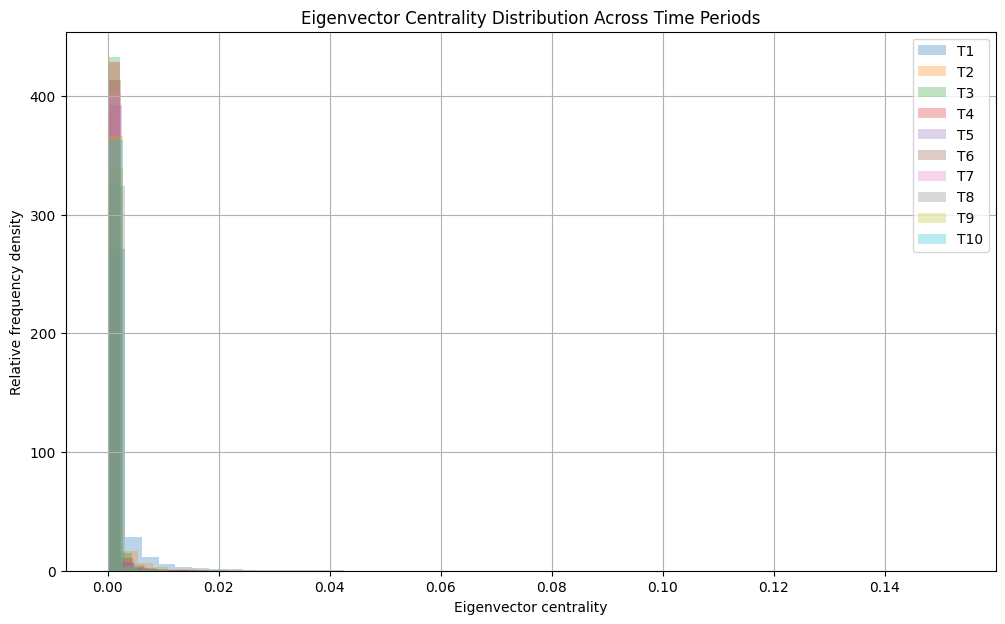

In [19]:
# plot eigenvector values for each period

plt.figure(figsize=(12, 7))

for i, centrality in enumerate(eigenvector_centralities, start=1):
    values = list(centrality.values())

    plt.hist(
        values,
        bins=50,
        density=True,
        alpha=0.3,
        label=f"T{i}"
    )

plt.xlabel("Eigenvector centrality")
plt.ylabel("Relative frequency density")
plt.title("Eigenvector Centrality Distribution Across Time Periods")
plt.legend()
plt.grid(True)
plt.show()

## Katz Centrality

Then, we calculate Katz centrality.

Note that Katz centrality can be computationally more sensitive because it involves solving an iterative system.
It will be tested on the first node, using a sample of 500 nodes.

In [21]:
# test Katz centrality on the first node
print("Calculating sampled Katz centrality for T1...")

sample_size = 500

sampled_nodes = random.sample(
    list(graphs[0].nodes()),
    min(sample_size, graphs[0].number_of_nodes())
)

sampled_graph = graphs[0].subgraph(sampled_nodes).copy()

katz_T1 = nx.katz_centrality(
    sampled_graph,
    alpha=0.005,
    beta=1.0,
    max_iter=100,
    tol=1e-06
)

print(f"Sampled graph: {sampled_graph.number_of_nodes():,} nodes")
print(f"Katz values: {len(katz_T1):,}")

Calculating sampled Katz centrality for T1...
Sampled graph: 500 nodes
Katz values: 500


In [22]:
# calculate Katz centralities for all 10 periods

katz_centralities = []

sample_size = 500

for i, G in enumerate(graphs, start=1):
    print(f"Calculating sampled Katz centrality for T{i}...")

    sampled_nodes = random.sample(
        list(G.nodes()),
        min(sample_size, G.number_of_nodes())
    )

    sampled_graph = G.subgraph(sampled_nodes).copy()

    centrality = nx.katz_centrality(
        sampled_graph,
        alpha=0.005,
        beta=1.0,
        max_iter=100,
        tol=1e-06
    )

    katz_centralities.append(centrality)

    print(
        f"  Sampled graph: {sampled_graph.number_of_nodes():,} nodes"
        f" | Katz values: {len(centrality):,}"
    )

Calculating sampled Katz centrality for T1...
  Sampled graph: 500 nodes | Katz values: 500
Calculating sampled Katz centrality for T2...
  Sampled graph: 500 nodes | Katz values: 500
Calculating sampled Katz centrality for T3...
  Sampled graph: 500 nodes | Katz values: 500
Calculating sampled Katz centrality for T4...
  Sampled graph: 500 nodes | Katz values: 500
Calculating sampled Katz centrality for T5...
  Sampled graph: 500 nodes | Katz values: 500
Calculating sampled Katz centrality for T6...
  Sampled graph: 500 nodes | Katz values: 500
Calculating sampled Katz centrality for T7...
  Sampled graph: 500 nodes | Katz values: 500
Calculating sampled Katz centrality for T8...
  Sampled graph: 500 nodes | Katz values: 500
Calculating sampled Katz centrality for T9...
  Sampled graph: 500 nodes | Katz values: 500
Calculating sampled Katz centrality for T10...
  Sampled graph: 500 nodes | Katz values: 500


## Plot Katz Centrality

Then, we plot all Katz centralities for all 10 periods using a sampled subgraph of 500.

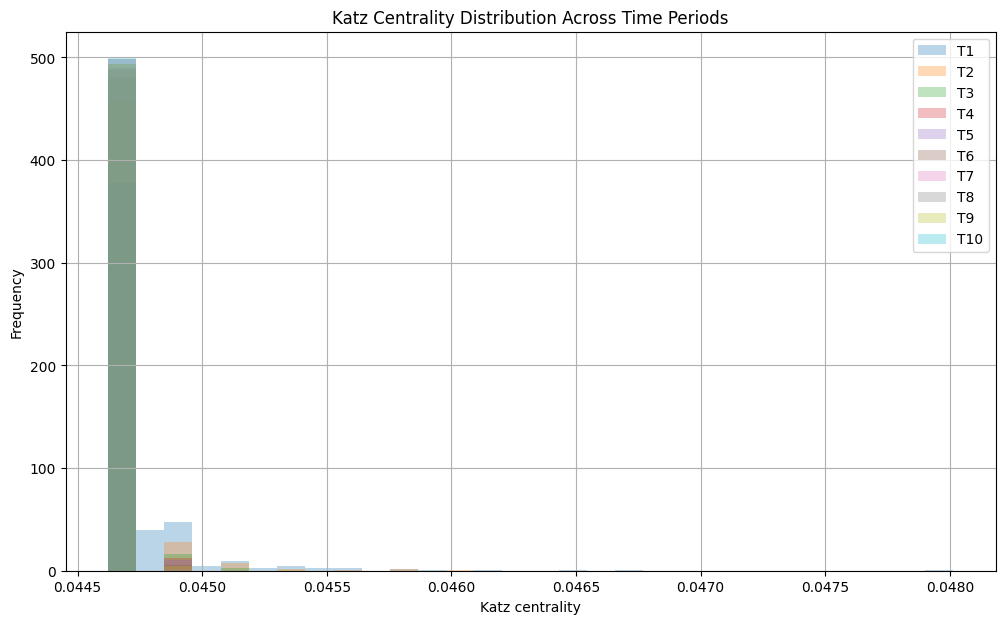

In [26]:
# plot all Katz centralities

plt.figure(figsize=(12, 7))

all_values = [
    value
    for centrality in katz_centralities
    for value in centrality.values()
]

xmin = min(all_values)
xmax = max(all_values)

for i, centrality in enumerate(katz_centralities, start=1):
    values = list(centrality.values())

    plt.hist(
        values,
        bins=30,
        range=(xmin, xmax),
        alpha=0.3,
        label=f"T{i}"
    )

plt.xlabel("Katz centrality")
plt.ylabel("Frequency")
plt.title("Katz Centrality Distribution Across Time Periods")
plt.legend()
plt.grid(True)
plt.show()